In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install dlib ultralytics facenet_pytorch

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

# **Preprocesses images and labels**

In [ ]:
import os
import cv2
import numpy as np
from scipy.spatial.transform import Rotation as R
from ultralytics import YOLO
from tqdm import tqdm

# Paths
BIWI_ROOT = '/content/drive/My Drive/HeadPose/BIWI'
FACES_0_DIR = os.path.join(BIWI_ROOT, 'faces_0')
OUTPUT_DIR = os.path.join(BIWI_ROOT, 'processed_data')
YOLO_MODEL_PATH = '/content/drive/My Drive/Models/yolov8n-face-lindevs.pt'

# Create output directories
os.makedirs(os.path.join(OUTPUT_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'labels'), exist_ok=True)

# Load YOLO face detection model
yolo_model = YOLO(YOLO_MODEL_PATH)

# Load OpenCV's Haar Cascade as fallback detector
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def parse_annotation(annotation_path):
    # Read BIWI annotation file and extract yaw, pitch, roll in degrees.
    try:
        with open(annotation_path, 'r') as f:
            lines = f.readlines()

        # Check if the file contains a rotation matrix (3 rows)
        if len(lines) >= 3 and all(len(line.strip().split()) == 3 for line in lines[:3]):
            # Parse rotation matrix
            rot_matrix = np.array([
                [float(x) for x in lines[0].strip().split()[:3]],
                [float(x) for x in lines[1].strip().split()[:3]],
                [float(x) for x in lines[2].strip().split()[:3]]
            ])

            # Convert to Euler angles (ZYX: yaw, pitch, roll in radians)
            euler_rad = R.from_matrix(rot_matrix).as_euler('ZYX', degrees=False)
            yaw, pitch, roll = np.degrees(euler_rad)

        else:
            # Parse Euler angles directly (single row)
            yaw, pitch, roll = map(float, lines[0].strip().split())

        return yaw, pitch, roll

    except Exception as e:
        tqdm.write(f"Error parsing annotation file {annotation_path}: {str(e)}")
        return None, None, None

def detect_face(image_path, yolo_model, haar_cascade):
    # Detect face in image using YOLO. If YOLO fails, use Haar Cascade as fallback.
    try:
        image = cv2.imread(image_path)
        if image is None:
            tqdm.write(f"Failed to load image: {image_path}")
            return None, None

        # Try YOLO first
        results = yolo_model(image, verbose=False)

        # Check if any faces were detected by YOLO
        if results[0].boxes is not None and len(results[0].boxes) > 0:
            # Select the largest bounding box
            boxes = results[0].boxes
            areas = [(box.xyxy[0][2] - box.xyxy[0][0]) * (box.xyxy[0][3] - box.xyxy[0][1]) for box in boxes]
            largest_box_idx = np.argmax(areas)
            box = boxes[largest_box_idx]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Validate bounding box coordinates
            h, w = image.shape[:2]
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
            cropped_face = image[y1:y2, x1:x2]

            # Resize to a fixed size
            cropped_face = cv2.resize(cropped_face, (224, 224))
            return cropped_face, (x1, y1, x2, y2)

        # If YOLO fails, try Haar Cascade
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        if len(faces) > 0:
            # Select the largest face
            areas = [w * h for (x, y, w, h) in faces]
            largest_face_idx = np.argmax(areas)
            x, y, w, h = faces[largest_face_idx]
            x1, y1, x2, y2 = x, y, x + w, y + h

            # Validate bounding box coordinates
            h_img, w_img = image.shape[:2]
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w_img, x2), min(h_img, y2)
            cropped_face = image[y1:y2, x1:x2]

            # Resize to a fixed size
            cropped_face = cv2.resize(cropped_face, (224, 224))
            return cropped_face, (x1, y1, x2, y2)

        # If both YOLO and Haar Cascade fail
        tqdm.write(f"No faces detected by YOLO or Haar Cascade in: {image_path}")
        return None, None

    except Exception as e:
        tqdm.write(f"Error detecting face in {image_path}: {str(e)}")
        return None, None

def save_cropped_face(cropped_face, output_dir, image_name):
    # Save cropped face image.
    try:
        output_path = os.path.join(output_dir, image_name)
        cv2.imwrite(output_path, cropped_face)
    except Exception as e:
        tqdm.write(f"Error saving cropped face to {output_path}: {str(e)}")

def preprocess_dataset():
    # Main preprocessing function for BIWI dataset.
    subfolders = [f for f in os.listdir(FACES_0_DIR) if os.path.isdir(os.path.join(FACES_0_DIR, f))]

    # Single progress bar for subfolders
    for subfolder in tqdm(subfolders, desc="Processing Subfolders", unit="subfolder"):
        subfolder_path = os.path.join(FACES_0_DIR, subfolder)

        image_files = [f for f in os.listdir(subfolder_path) if f.endswith('_rgb.png')]

        for file_name in image_files:
            base_name = file_name.split('_rgb.png')[0]
            annotation_file = f"{base_name}_pose.txt"
            annotation_path = os.path.join(subfolder_path, annotation_file)
            image_path = os.path.join(subfolder_path, file_name)

            if os.path.exists(annotation_path):
                try:
                    yaw, pitch, roll = parse_annotation(annotation_path)
                    if yaw is None or pitch is None or roll is None:
                        tqdm.write(f"Skipping invalid annotation: {annotation_path}")
                        continue

                    cropped_face, bbox = detect_face(image_path, yolo_model, haar_cascade)

                    if cropped_face is not None:
                        new_image_name = f"{subfolder}_{file_name}"
                        save_cropped_face(cropped_face, os.path.join(OUTPUT_DIR, 'images'), new_image_name)

                        # Save separate label file for each image
                        label_file_path = os.path.join(OUTPUT_DIR, 'labels', f"{subfolder}_{base_name}.txt")
                        with open(label_file_path, 'w') as f:
                            f.write(f"{pitch:.3f} {yaw:.3f} {roll:.3f}\n")
                    else:
                        tqdm.write(f"No face detected in: {image_path}")

                except Exception as e:
                    tqdm.write(f"Error processing {image_path}: {str(e)}")
                    with open("error_log.txt", "a") as log_file:
                        log_file.write(f"Error processing {image_path}: {str(e)}\n")
            else:
                tqdm.write(f"Annotation file missing for: {image_path}")

    print(f"Dataset preprocessing complete. Cropped images and labels saved to {OUTPUT_DIR}")

if __name__ == "__main__":
    preprocess_dataset()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Processing Subfolders:  58%|█████▊    | 14/24 [53:14<41:00, 246.01s/subfolder]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/BIWI/faces_0/15/frame_00329_rgb.png
No face detected in: /content/drive/My Drive/HeadPose/BIWI/faces_0/15/frame_00329_rgb.png


Processing Subfolders:  58%|█████▊    | 14/24 [53:19<41:00, 246.01s/subfolder]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/BIWI/faces_0/15/frame_00344_rgb.png
No face detected in: /content/drive/My Drive/HeadPose/BIWI/faces_0/15/frame_00344_rgb.png


...

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/BIWI/faces_0/24/frame_00143_rgb.png
No face detected in: /content/drive/My Drive/HeadPose/BIWI/faces_0/24/frame_00143_rgb.png


Processing Subfolders:  96%|█████████▌| 23/24 [1:38:06<04:11, 251.90s/subfolder]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/BIWI/faces_0/24/frame_00156_rgb.png
No face detected in: /content/drive/My Drive/HeadPose/BIWI/faces_0/24/frame_00156_rgb.png


Processing Subfolders: 100%|██████████| 24/24 [1:38:07<00:00, 245.30s/subfolder]

Dataset preprocessing complete. Cropped images and labels saved to /content/drive/My Drive/HeadPose/BIWI/processed_data


# **Checks the integrity of the dataset**

In [ ]:
import os

# Paths
IMAGES_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/images'
LABELS_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/labels'

def match_image_label_pairs():
    # Match image files with their corresponding label files.
    image_files = {f for f in os.listdir(IMAGES_DIR) if f.endswith('.png') or f.endswith('.jpg')}
    label_files = {f for f in os.listdir(LABELS_DIR) if f.endswith('.txt')}

    # Remove extensions and suffixes for comparison
    image_names = {os.path.splitext(f)[0].replace('_rgb', '') for f in image_files}
    label_names = {os.path.splitext(f)[0] for f in label_files}

    # Identify mismatches
    matched_pairs = []
    missing_labels = []
    missing_images = []

    for image_name in image_names:
        if image_name in label_names:
            matched_pairs.append((f"{image_name}_rgb.png", f"{image_name}.txt"))
        else:
            missing_labels.append(f"{image_name}_rgb.png")

    for label_name in label_names:
        if label_name not in image_names:
            missing_images.append(f"{label_name}.txt")

    # Print missing labels
    if missing_labels:
        print("\nImages without labels:")
        for image_file in sorted(missing_labels):
            print(f"- {image_file}")

    # Print missing images
    if missing_images:
        print("\nLabels without images:")
        for label_file in sorted(missing_images):
            print(f"- {label_file}")

    # Summary
    print("\nSummary:")
    print(f"- Total matched pairs: {len(matched_pairs)}")
    print(f"- Total images without labels: {len(missing_labels)}")
    print(f"- Total labels without images: {len(missing_images)}")

if __name__ == "__main__":
    match_image_label_pairs()


Summary:
- Total matched pairs: 15549
- Total images without labels: 0
- Total labels without images: 0


# **Checks for bias in the dataset**

Visualizing angle distributions...


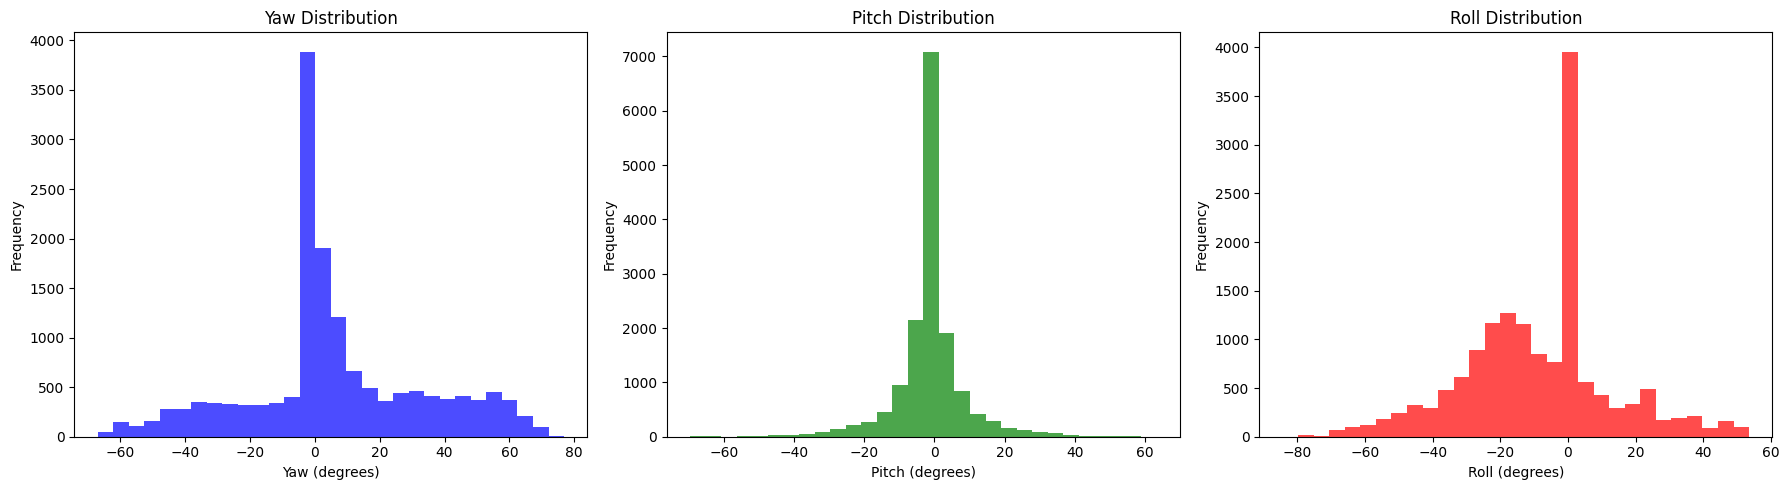

Visualizing relationships between angles...


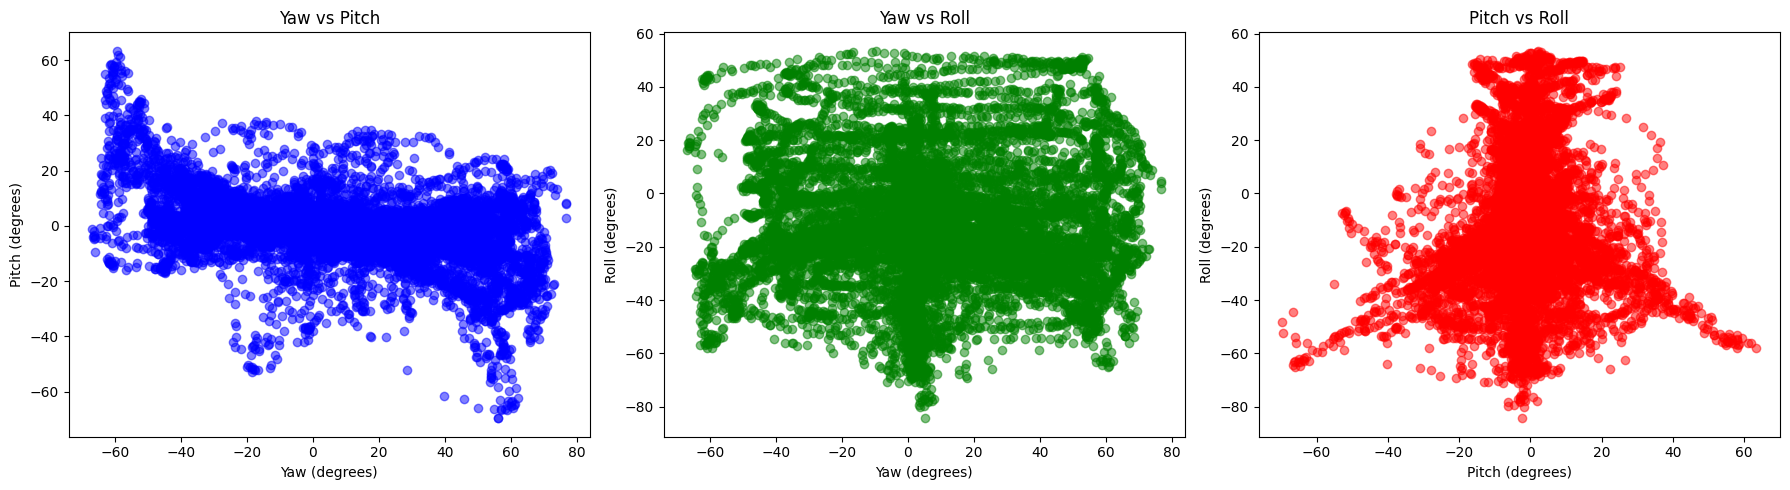

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Paths
LABELS_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/labels'

def extract_pose_annotations():
    # Extract yaw, pitch, and roll values from label files.
    yaws, pitches, rolls = [], [], []
    for label_file in os.listdir(LABELS_DIR):
        if label_file.endswith('.txt'):
            label_path = os.path.join(LABELS_DIR, label_file)
            try:
                with open(label_path, 'r') as f:
                    yaw, pitch, roll = map(float, f.readline().strip().split())
                    yaws.append(yaw)
                    pitches.append(pitch)
                    rolls.append(roll)
            except Exception as e:
                print(f"Error reading {label_path}: {str(e)}")
    return np.array(yaws), np.array(pitches), np.array(rolls)

def plot_histograms(yaws, pitches, rolls):
    # Plot histograms for yaw, pitch, and roll.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].hist(yaws, bins=30, color='blue', alpha=0.7)
    axes[0].set_title("Yaw Distribution")
    axes[0].set_xlabel("Yaw (degrees)")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(pitches, bins=30, color='green', alpha=0.7)
    axes[1].set_title("Pitch Distribution")
    axes[1].set_xlabel("Pitch (degrees)")
    axes[1].set_ylabel("Frequency")

    axes[2].hist(rolls, bins=30, color='red', alpha=0.7)
    axes[2].set_title("Roll Distribution")
    axes[2].set_xlabel("Roll (degrees)")
    axes[2].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

def plot_scatter_plots(yaws, pitches, rolls):
    # Plot scatter plots for yaw vs pitch, yaw vs roll, and pitch vs roll.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Yaw vs Pitch
    axes[0].scatter(yaws, pitches, alpha=0.5, color='blue')
    axes[0].set_title("Yaw vs Pitch")
    axes[0].set_xlabel("Yaw (degrees)")
    axes[0].set_ylabel("Pitch (degrees)")

    # Yaw vs Roll
    axes[1].scatter(yaws, rolls, alpha=0.5, color='green')
    axes[1].set_title("Yaw vs Roll")
    axes[1].set_xlabel("Yaw (degrees)")
    axes[1].set_ylabel("Roll (degrees)")

    # Pitch vs Roll
    axes[2].scatter(pitches, rolls, alpha=0.5, color='red')
    axes[2].set_title("Pitch vs Roll")
    axes[2].set_xlabel("Pitch (degrees)")
    axes[2].set_ylabel("Roll (degrees)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Extract pose annotations
    yaws, pitches, rolls = extract_pose_annotations()

    # Plot histograms
    print("Visualizing angle distributions...")
    plot_histograms(yaws, pitches, rolls)

    # Plot scatter plots
    print("Visualizing relationships between angles...")
    plot_scatter_plots(yaws, pitches, rolls)

# **Copy extreme poses to fix bias**

In [ ]:
import os
import numpy as np
from scipy.io import loadmat
from tqdm import tqdm

# Paths
LP_ROOT = '/content/drive/My Drive/HeadPose/300W_LP/LFPW/'
IMAGES_DIR = LP_ROOT
LABELS_DIR = LP_ROOT

FILTERED_IMAGES_DIR = '/content/drive/My Drive/HeadPose/300W_LP/filtered_images'
FILTERED_LABELS_DIR = '/content/drive/My Drive/HeadPose/300W_LP/filtered_labels'

# Create output directories if they don't exist
os.makedirs(FILTERED_IMAGES_DIR, exist_ok=True)
os.makedirs(FILTERED_LABELS_DIR, exist_ok=True)

# Define thresholds for filtering
YAW_THRESHOLD = 20  # Degrees for extreme yaw
PITCH_THRESHOLD = 20
ROLL_THRESHOLD = 20

def load_pose_annotations(label_path):
    # Load pose parameters from a .mat file.
    mat_data = loadmat(label_path)
    pose_para = mat_data['Pose_Para'][0]
    return pose_para

def filter_poses_from_300W_LP():
    # Filter images and labels based on pose angles.
    filtered_images = []
    filtered_labels = []

    # Get all .mat files in the labels directory
    label_files = [f for f in os.listdir(LABELS_DIR) if f.endswith('.mat')]

    # Wrap the loop with tqdm for progress tracking
    for label_file in tqdm(label_files, desc="Filtering poses"):
        label_path = os.path.join(LABELS_DIR, label_file)
        image_name = label_file.replace('.mat', '.jpg')
        image_path = os.path.join(IMAGES_DIR, image_name)

        # Check if the corresponding image exists
        if not os.path.exists(image_path):
            print(f"\nImage {image_path} does not exist for label {label_file}. Skipping.")
            continue

        # Load pose parameters
        try:
            pose_para = load_pose_annotations(label_path)
            pitch, yaw, roll = pose_para[:3] * 180 / np.pi  # Convert to degrees
        except Exception as e:
            print(f"\nError reading {label_path}: {str(e)}")
            continue

        # Filter based on thresholds for extreme poses only
        if (
            (yaw > YAW_THRESHOLD) or  # Rightward poses
            (yaw < -YAW_THRESHOLD) or  # Leftward poses
            (pitch > PITCH_THRESHOLD) or  # Upward poses
            (pitch < -PITCH_THRESHOLD) or  # Downward poses
            (roll > ROLL_THRESHOLD) or  # Extreme roll
            (roll < -ROLL_THRESHOLD)
        ):
            # Copy image and label to filtered directories
            filtered_images.append(image_name)
            filtered_labels.append(label_file)

            # Copy image
            new_image_path = os.path.join(FILTERED_IMAGES_DIR, image_name)
            os.system(f"cp '{image_path}' '{new_image_path}'")  # Quotes handle paths with spaces

            # Copy label
            new_label_path = os.path.join(FILTERED_LABELS_4DIR, label_file)
            os.system(f"cp '{label_path}' '{new_label_path}'")

    print(f"\nFiltered {len(filtered_images)} images and labels.")
    return filtered_images, filtered_labels

if __name__ == "__main__":
    filtered_images, filtered_labels = filter_poses_from_300W_LP()

Filtering poses: 100%|██████████| 16556/16556 [24:05<00:00, 11.46it/s]


Filtered 14492 images and labels.


# **preprocesse filtered data**

In [ ]:
import os
import cv2
import numpy as np
from scipy.io import loadmat
from ultralytics import YOLO
from tqdm import tqdm

# Paths
IMAGES_DIR = '/content/drive/My Drive/HeadPose/300W_LP/filtered_images'
FILTERED_LABELS_DIR = '/content/drive/My Drive/HeadPose/300W_LP/filtered_labels'
OUTPUT_DIR = os.path.join('/content/drive/My Drive/HeadPose/300W_LP/', 'processed_data')
YOLO_MODEL_PATH = '/content/drive/My Drive/Models/yolov8n-face-lindevs.pt'

# Create output directories
os.makedirs(os.path.join(OUTPUT_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'labels'), exist_ok=True)

# Load YOLO face detection model
yolo_model = YOLO(YOLO_MODEL_PATH)

# Load OpenCV's Haar Cascade as fallback detector
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def parse_annotation(annotation_path):
    # Read .mat annotation file and extract yaw, pitch, roll in degrees.
    try:
        mat_data = loadmat(annotation_path)
        pose_para = mat_data['Pose_Para'][0]
        pitch, yaw, roll = pose_para[:3] * 180 / np.pi  # Convert to degrees
        return yaw, pitch, roll
    except Exception as e:
        tqdm.write(f"Error parsing annotation file {annotation_path}: {str(e)}")
        return None, None, None

def detect_face(image_path, yolo_model, haar_cascade):
    # Detect face in image using YOLO. If YOLO fails, use Haar Cascade as fallback.
    try:
        image = cv2.imread(image_path)
        if image is None:
            tqdm.write(f"Failed to load image: {image_path}")
            return None, None

        # Try YOLO first
        results = yolo_model(image, verbose=False)

        # Check if any faces were detected by YOLO
        if results[0].boxes is not None and len(results[0].boxes) > 0:
            # Select the largest bounding box
            boxes = results[0].boxes
            areas = [(box.xyxy[0][2] - box.xyxy[0][0]) * (box.xyxy[0][3] - box.xyxy[0][1]) for box in boxes]
            largest_box_idx = np.argmax(areas)
            box = boxes[largest_box_idx]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Validate bounding box coordinates
            h, w = image.shape[:2]
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
            cropped_face = image[y1:y2, x1:x2]

            # Resize to a fixed size
            cropped_face = cv2.resize(cropped_face, (224, 224))
            return cropped_face, (x1, y1, x2, y2)

        # If YOLO fails, try Haar Cascade
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        if len(faces) > 0:
            # Select the largest face
            areas = [w * h for (x, y, w, h) in faces]
            largest_face_idx = np.argmax(areas)
            x, y, w, h = faces[largest_face_idx]
            x1, y1, x2, y2 = x, y, x + w, y + h

            # Validate bounding box coordinates
            h_img, w_img = image.shape[:2]
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w_img, x2), min(h_img, y2)
            cropped_face = image[y1:y2, x1:x2]

            # Resize to a fixed size
            cropped_face = cv2.resize(cropped_face, (224, 224))
            return cropped_face, (x1, y1, x2, y2)

        # If both YOLO and Haar Cascade fail
        tqdm.write(f"No faces detected by YOLO or Haar Cascade in: {image_path}")
        return None, None

    except Exception as e:
        tqdm.write(f"Error detecting face in {image_path}: {str(e)}")
        return None, None

def save_cropped_face_and_pose(cropped_face, yaw, pitch, roll, output_dir, image_name):
    # Save cropped face image and corresponding pose values.
    try:
        # Save cropped face
        image_output_path = os.path.join(output_dir, 'images', image_name)
        cv2.imwrite(image_output_path, cropped_face)

        # Save pose values
        label_output_path = os.path.join(output_dir, 'labels', f"{image_name.split('.')[0]}.txt")
        with open(label_output_path, 'w') as f:
            f.write(f"{pitch:.3f} {yaw:.3f} {roll:.3f}\n")
    except Exception as e:
        tqdm.write(f"Error saving cropped face or pose to {output_dir}: {str(e)}")

def preprocess_dataset():
    image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg') or f.endswith('_rgb.png')]

    for image_file in tqdm(image_files, desc="Processing Images", unit="image"):
        base_name = image_file.split('.')[0]  # Remove extension
        annotation_file = f"{base_name}.mat"
        annotation_path = os.path.join(FILTERED_LABELS_DIR, annotation_file)
        image_path = os.path.join(IMAGES_DIR, image_file)

        # Check if the corresponding .mat file exists
        if os.path.exists(annotation_path):
            try:
                # Parse the annotation file
                yaw, pitch, roll = parse_annotation(annotation_path)

                if yaw is None or pitch is None or roll is None:
                    tqdm.write(f"Skipping invalid annotation: {annotation_path}")
                    continue

                # Detect and crop the face
                cropped_face, bbox = detect_face(image_path, yolo_model, haar_cascade)

                if cropped_face is not None:
                    # Save the cropped face and pose values
                    save_cropped_face_and_pose(cropped_face, yaw, pitch, roll, OUTPUT_DIR, image_file)
                else:
                    tqdm.write(f"No face detected in: {image_path}")

            except Exception as e:
                tqdm.write(f"Error processing {image_path}: {str(e)}")
                with open("error_log.txt", "a") as log_file:
                    log_file.write(f"Error processing {image_path}: {str(e)}\n")
        else:
            tqdm.write(f"Annotation file missing for: {image_file}")

    print(f"Dataset preprocessing complete. Cropped images and labels saved to {OUTPUT_DIR}")

if __name__ == "__main__":
    preprocess_dataset()

Processing Images:   1%|▏         | 185/14492 [12:15<2:02:25,  1.95image/s]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_test_0046_11.jpg
No face detected in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_test_0046_11.jpg


Processing Images:   1%|▏         | 186/14492 [12:16<1:58:47,  2.01image/s]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_test_0046_12.jpg
No face detected in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_test_0046_12.jpg


Processing Images:   1%|▏         | 188/14492 [12:17<1:48:31,  2.20image/s]

...

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_train_0860_4.jpg
No face detected in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_train_0860_4.jpg


Processing Images:  98%|█████████▊| 14273/14492 [1:59:35<01:27,  2.51image/s]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_train_0860_9.jpg
No face detected in: /content/drive/My Drive/HeadPose/300W_LP/filtered_images/LFPW_image_train_0860_9.jpg


Processing Images: 100%|██████████| 14492/14492 [2:01:03<00:00,  2.00image/s]

Dataset preprocessing complete. Cropped images and labels saved to /content/drive/My Drive/HeadPose/300W_LP/processed_data


# **Merge the 2 datasets to fix bias**

Loading poses from /content/drive/My Drive/HeadPose/BIWI/processed_data/labels: 100%|██████████| 15549/15549 [08:11<00:00, 31.61file/s] 
Loading poses from /content/drive/My Drive/HeadPose/300W_LP/processed_data/labels: 100%|██████████| 14365/14365 [02:28<00:00, 96.59file/s] 


Loaded 15549 poses from BIWI dataset.
Loaded 14365 poses from 300W_LP dataset.


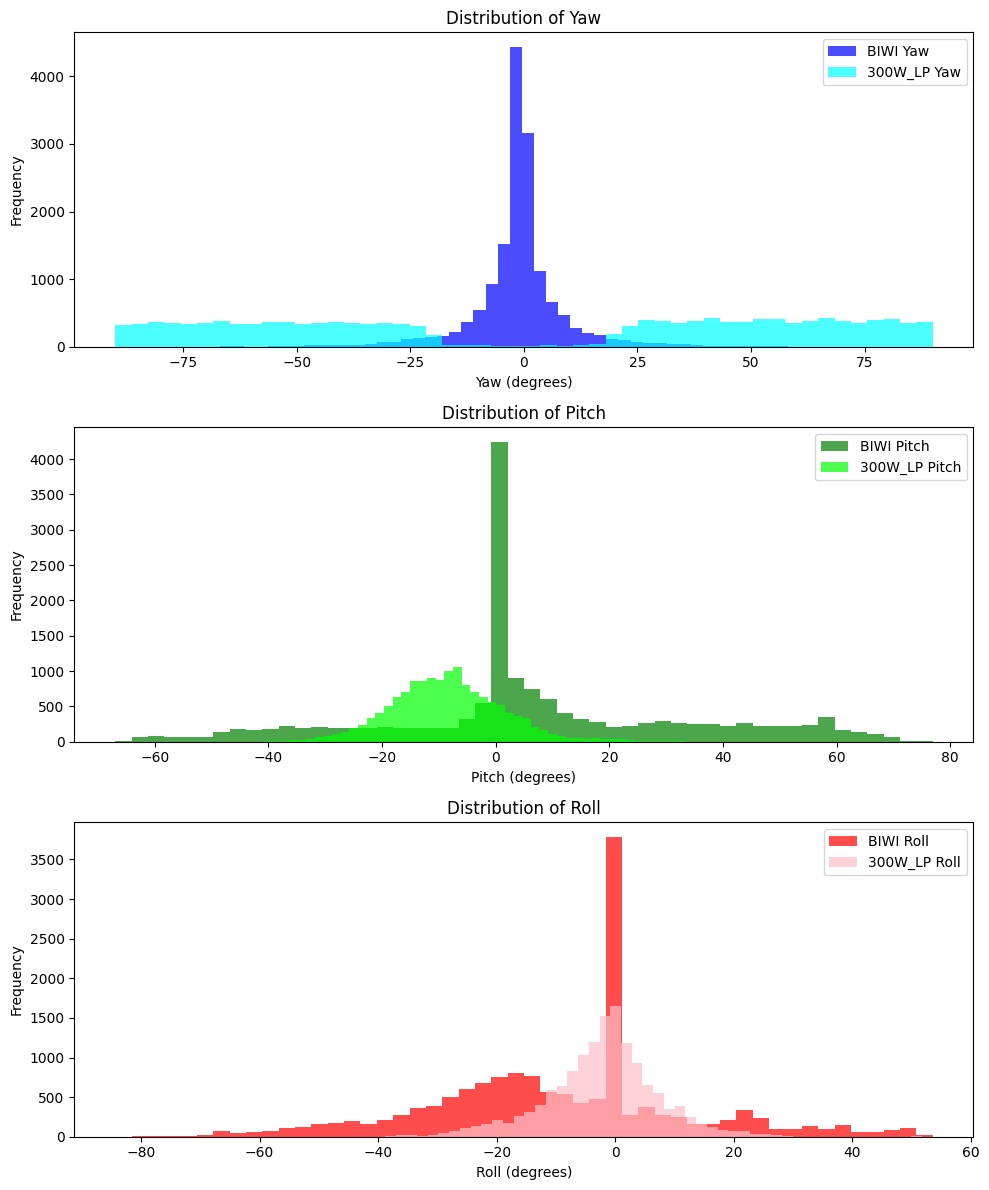

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
BIWI_LABELS_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/labels'
LFPW_LABELS_DIR = '/content/drive/My Drive/HeadPose/300W_LP/processed_data/labels'

def load_poses(labels_dir):
    # Load yaw, pitch, roll values from .txt files in the given directory.
    poses = []
    for file_name in tqdm(os.listdir(labels_dir), desc=f"Loading poses from {labels_dir}", unit="file"):
        if file_name.endswith('.txt'):
            file_path = os.path.join(labels_dir, file_name)
            try:
                with open(file_path, 'r') as f:
                    line = f.readline().strip()
                    pitch, yaw, roll = map(float, line.split())
                    poses.append((yaw, pitch, roll))
            except Exception as e:
                print(f"Error loading pose from {file_path}: {str(e)}")
    return np.array(poses)

def plot_pose_distributions(biwi_poses, lfpw_poses):
    # Plot histograms to compare pose distributions.
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    labels = ['Yaw', 'Pitch', 'Roll']
    biwi_colors = ['blue', 'green', 'red']
    lfpw_colors = ['cyan', 'lime', 'pink']

    for i, label in enumerate(labels):
        axes[i].hist(biwi_poses[:, i], bins=50, color=biwi_colors[i], alpha=0.7, label=f'BIWI {label}')
        axes[i].hist(lfpw_poses[:, i], bins=50, color=lfpw_colors[i], alpha=0.7, label=f'300W_LP {label}')
        axes[i].set_title(f"Distribution of {label}")
        axes[i].set_xlabel(label + " (degrees)")
        axes[i].set_ylabel("Frequency")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

def compare_datasets():
    # Compare pose distributions between BIWI and 300W_LP datasets.
    biwi_poses = load_poses(BIWI_LABELS_DIR)
    lfpw_poses = load_poses(LFPW_LABELS_DIR)

    if len(biwi_poses) == 0 or len(lfpw_poses) == 0:
        print("No pose data found in one or both datasets.")
        return

    print(f"Loaded {len(biwi_poses)} poses from BIWI dataset.")
    print(f"Loaded {len(lfpw_poses)} poses from 300W_LP dataset.")

    # Plot pose distributions
    plot_pose_distributions(biwi_poses, lfpw_poses)

if __name__ == "__main__":
    compare_datasets()

In [ ]:
import os
from collections import Counter
from tqdm import tqdm

# Paths for labels
BIWI_LABELS_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/labels'
LFPW_LABELS_DIR = '/content/drive/My Drive/HeadPose/300W_LP/processed_data/labels'

# Define thresholds for pose classification
YAW_THRESHOLD = 15  # Degrees to classify as left/right
PITCH_THRESHOLD = 15  # Degrees to classify as up/down
ROLL_THRESHOLD = 15  # Degrees to classify as tilted left/right

def classify_pose(yaw, pitch):
    # Classify pose into one of the categories: right, left, frontal, up, down.
    if yaw > YAW_THRESHOLD:
        return "right"
    elif yaw < -YAW_THRESHOLD:
        return "left"
    elif pitch > PITCH_THRESHOLD:
        return "up"
    elif pitch < -PITCH_THRESHOLD:
        return "down"
    else:
        return "frontal"

def analyze_pose_distribution(labels_dir):
    # Analyze the distribution of poses in a dataset.
    pose_counts = Counter()

    for file_name in tqdm(os.listdir(labels_dir), desc=f"Analyzing {labels_dir}", unit="file"):
        if file_name.endswith('.txt'):
            file_path = os.path.join(labels_dir, file_name)
            try:
                with open(file_path, 'r') as f:
                    line = f.readline().strip()
                    pitch, yaw, roll = map(float, line.split())
                    pose_category = classify_pose(yaw, pitch)
                    pose_counts[pose_category] += 1
            except Exception as e:
                print(f"Error processing {file_path}: {str(e)}")

    return pose_counts

def check_balance():
    # Check pose balance in both datasets.
    print("Analyzing BIWI dataset...")
    biwi_pose_counts = analyze_pose_distribution(BIWI_LABELS_DIR)

    print("\nAnalyzing 300W_LP dataset...")
    lfpw_pose_counts = analyze_pose_distribution(LFPW_LABELS_DIR)

    # Print results
    print("\nBIWI Pose Distribution:")
    for pose, count in biwi_pose_counts.items():
        print(f"{pose.capitalize()}: {count} samples")

    print("\n300W_LP Pose Distribution:")
    for pose, count in lfpw_pose_counts.items():
        print(f"{pose.capitalize()}: {count} samples")

if __name__ == "__main__":
    check_balance()

Analyzing BIWI dataset...


Analyzing /content/drive/My Drive/HeadPose/BIWI/processed_data/labels: 100%|██████████| 15549/15549 [02:48<00:00, 92.19file/s] 



Analyzing 300W_LP dataset...


Analyzing /content/drive/My Drive/HeadPose/300W_LP/processed_data/labels: 100%|██████████| 14365/14365 [02:33<00:00, 93.85file/s] 


BIWI Pose Distribution:
Frontal: 8170 samples
Left: 1012 samples
Right: 792 samples
Down: 2066 samples
Up: 3509 samples

300W_LP Pose Distribution:
Left: 6804 samples
Right: 7418 samples
Down: 102 samples
Up: 13 samples
Frontal: 28 samples


In [ ]:
import os
import shutil
from tqdm import tqdm

# Paths for original datasets
BIWI_IMAGES_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/images'
BIWI_LABELS_DIR = '/content/drive/My Drive/HeadPose/BIWI/processed_data/labels'

LFPW_IMAGES_DIR = '/content/drive/My Drive/HeadPose/300W_LP/processed_data/images'
LFPW_LABELS_DIR = '/content/drive/My Drive/HeadPose/300W_LP/processed_data/labels'

# Output directory for the merged dataset
MERGED_DATASET_DIR = '/content/drive/My Drive/HeadPose/Merged_Dataset'
MERGED_IMAGES_DIR = os.path.join(MERGED_DATASET_DIR, 'images')
MERGED_LABELS_DIR = os.path.join(MERGED_DATASET_DIR, 'labels')

# Create output directories
os.makedirs(MERGED_IMAGES_DIR, exist_ok=True)
os.makedirs(MERGED_LABELS_DIR, exist_ok=True)

def merge_datasets():
    # Merge images and labels from two datasets.
    biwi_image_files = [f for f in os.listdir(BIWI_IMAGES_DIR) if f.endswith('.jpg') or f.endswith('_rgb.png')]
    lfpw_image_files = [f for f in os.listdir(LFPW_IMAGES_DIR) if f.endswith('.jpg') or f.endswith('_rgb.png')]

    # Copy BIWI images
    print("Copying BIWI images...")
    for image_file in tqdm(biwi_image_files, desc="BIWI Images", unit="image"):
        src_image_path = os.path.join(BIWI_IMAGES_DIR, image_file)
        dst_image_path = os.path.join(MERGED_IMAGES_DIR, image_file)
        shutil.copy(src_image_path, dst_image_path)

    # Copy BIWI labels
    print("\nCopying BIWI labels...")
    for label_file in tqdm(os.listdir(BIWI_LABELS_DIR), desc="BIWI Labels", unit="label"):
        if label_file.endswith('.txt'):
            src_label_path = os.path.join(BIWI_LABELS_DIR, label_file)
            dst_label_path = os.path.join(MERGED_LABELS_DIR, label_file)
            shutil.copy(src_label_path, dst_label_path)

    # Copy LFPW images
    print("\nCopying 300W_LP images...")
    for image_file in tqdm(lfpw_image_files, desc="300W_LP Images", unit="image"):
        src_image_path = os.path.join(LFPW_IMAGES_DIR, image_file)
        dst_image_path = os.path.join(MERGED_IMAGES_DIR, image_file)
        shutil.copy(src_image_path, dst_image_path)

    # Copy LFPW labels
    print("\nCopying 300W_LP labels...")
    for label_file in tqdm(os.listdir(LFPW_LABELS_DIR), desc="300W_LP Labels", unit="label"):
        if label_file.endswith('.txt'):
            src_label_path = os.path.join(LFPW_LABELS_DIR, label_file)
            dst_label_path = os.path.join(MERGED_LABELS_DIR, label_file)
            shutil.copy(src_label_path, dst_label_path)

    print("\nMerging complete. Merged dataset saved to:", MERGED_DATASET_DIR)

if __name__ == "__main__":
    merge_datasets()

Copying BIWI images...


BIWI Images: 100%|██████████| 15549/15549 [06:21<00:00, 40.75image/s] 



Copying BIWI labels...


BIWI Labels: 100%|██████████| 15549/15549 [04:34<00:00, 56.56label/s] 



Copying 300W_LP images...


300W_LP Images: 100%|██████████| 14365/14365 [01:58<00:00, 121.34image/s]



Copying 300W_LP labels...


300W_LP Labels: 100%|██████████| 14365/14365 [04:02<00:00, 59.14label/s] 


Merging complete. Merged dataset saved to: /content/drive/My Drive/HeadPose/Merged_Dataset


Loading poses from /content/drive/My Drive/HeadPose/Merged_Dataset/labels: 100%|██████████| 29914/29914 [08:42<00:00, 57.27file/s] 


Loaded 29914 poses from the merged dataset.


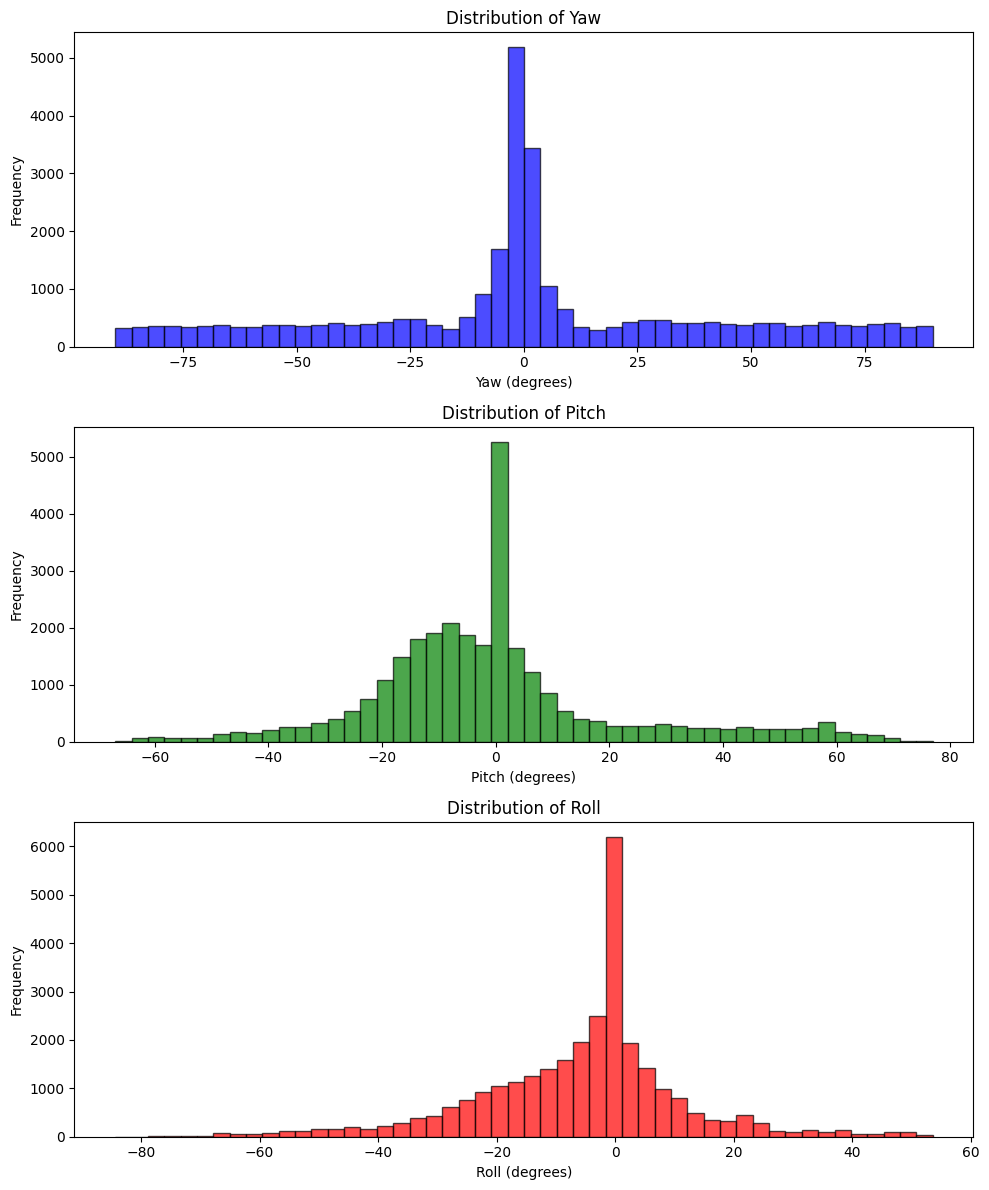

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths for the merged dataset
MERGED_LABELS_DIR = '/content/drive/My Drive/HeadPose/Merged_Dataset/labels'

def load_poses(labels_dir):
    # Load yaw, pitch, roll values from .txt files in the given directory.
    poses = []
    for file_name in tqdm(os.listdir(labels_dir), desc=f"Loading poses from {labels_dir}", unit="file"):
        if file_name.endswith('.txt'):
            file_path = os.path.join(labels_dir, file_name)
            try:
                with open(file_path, 'r') as f:
                    line = f.readline().strip()
                    pitch, yaw, roll = map(float, line.split())
                    poses.append((yaw, pitch, roll))
            except Exception as e:
                print(f"Error loading pose from {file_path}: {str(e)}")
    return np.array(poses)

def plot_pose_distributions(poses):
    # Plot histograms to visualize pose distributions.
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    labels = ['Yaw', 'Pitch', 'Roll']
    colors = ['blue', 'green', 'red']

    for i, label in enumerate(labels):
        axes[i].hist(poses[:, i], bins=50, color=colors[i], alpha=0.7, edgecolor='black')
        axes[i].set_title(f"Distribution of {label}")
        axes[i].set_xlabel(label + " (degrees)")
        axes[i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

def visualize_merged_dataset():
    # Visualize pose distributions for the merged dataset.
    merged_poses = load_poses(MERGED_LABELS_DIR)

    if len(merged_poses) == 0:
        print("No pose data found in the merged dataset.")
        return

    print(f"Loaded {len(merged_poses)} poses from the merged dataset.")

    # Plot pose distributions
    plot_pose_distributions(merged_poses)

if __name__ == "__main__":
    visualize_merged_dataset()

Loading poses from /content/drive/My Drive/HeadPose/Merged_Dataset/labels: 100%|██████████| 29914/29914 [09:31<00:00, 52.38file/s] 


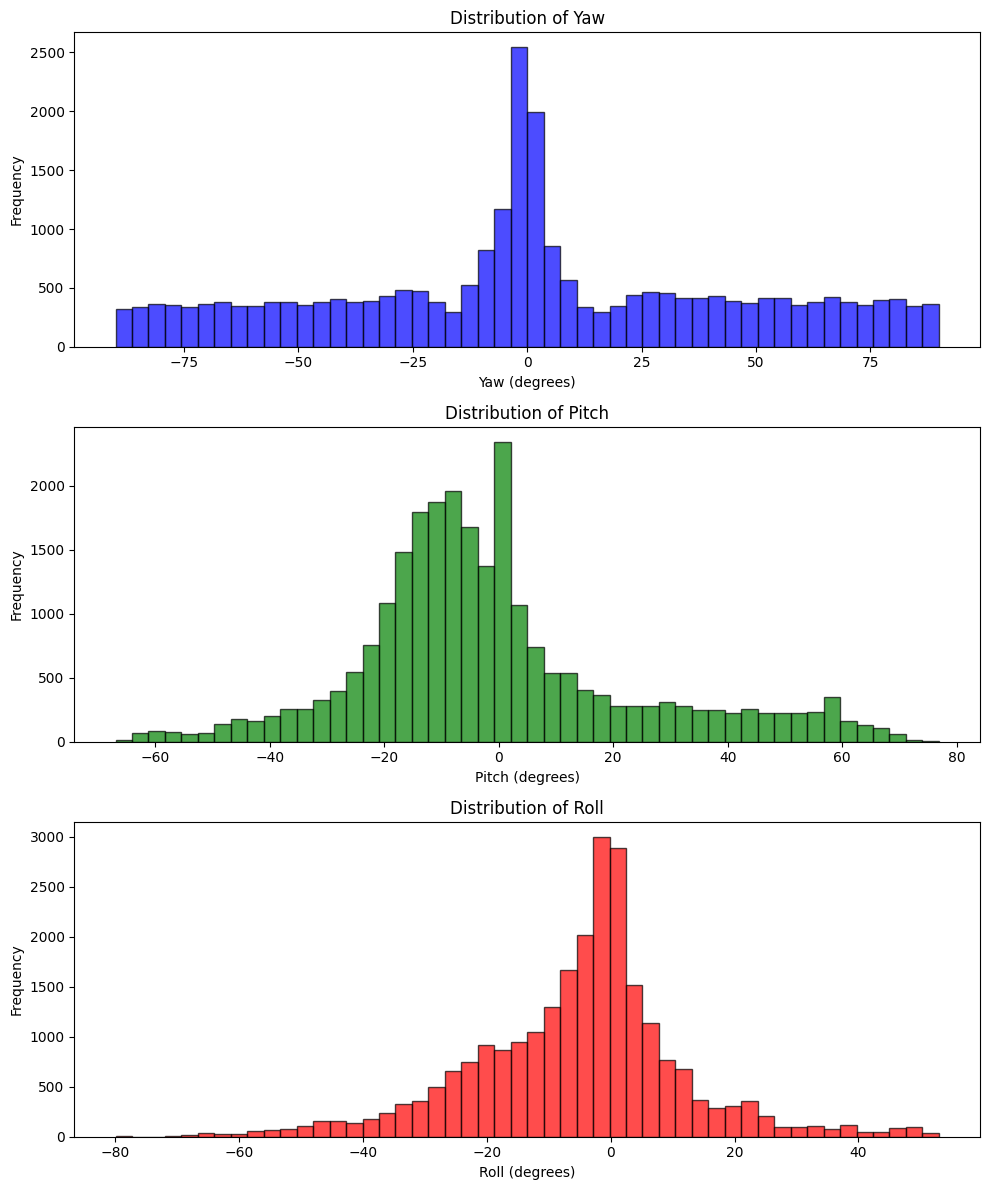

In [ ]:
import numpy as np
import random

def undersample_neutral_poses(poses, threshold=10):
    # Undersample neutral poses (yaw and pitch close to 0).
    neutral_poses = []
    non_neutral_poses = []

    for yaw, pitch, roll in poses:
        if abs(yaw) < threshold and abs(pitch) < threshold:
            neutral_poses.append((yaw, pitch, roll))
        else:
            non_neutral_poses.append((yaw, pitch, roll))

    # Randomly sample a subset of neutral poses
    neutral_subset = random.sample(neutral_poses, int(len(neutral_poses) * 0.3))  # Keep 30% of neutral poses
    balanced_poses = non_neutral_poses + neutral_subset
    return np.array(balanced_poses)

# Load poses
merged_poses = load_poses(MERGED_LABELS_DIR)

# Undersample neutral poses
balanced_poses = undersample_neutral_poses(merged_poses)

# Plot the balanced distributions
plot_pose_distributions(balanced_poses)

# Train with under sample and weighted poses

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import lru_cache
import random

# Dataset Class
class OptimizedHeadPoseDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None, max_workers=4, balance_poses=False):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.pose_categories = defaultdict(list)
        self.pose_weights = {}
        self.samples = []
        self.valid_indices = []  # Track valid samples only

        # Updated normalization parameters based on your data distributions
        self.angle_ranges = {
            'yaw': (-75, 75),
            'pitch': (-60, 80),
            'roll': (-80, 40)
        }

        # Calculate normalization factors for each angle
        self.normalization_factors = {
            'yaw': 1.0 / max(abs(self.angle_ranges['yaw'][0]), abs(self.angle_ranges['yaw'][1])),
            'pitch': 1.0 / max(abs(self.angle_ranges['pitch'][0]), abs(self.angle_ranges['pitch'][1])),
            'roll': 1.0 / max(abs(self.angle_ranges['roll'][0]), abs(self.angle_ranges['roll'][1]))
        }

        self.POSE_THRESHOLDS = {
            'frontal': (-15, 15),
            'left': (15, float('inf')),
            'right': (-float('inf'), -15),
            'up': (15, float('inf')),
            'down': (-float('inf'), -15)
        }

        self._parallel_load_and_categorize(max_workers)

        if balance_poses:
            self._balance_poses()

        self._calculate_pose_weights()

        # Create sample weights only for valid samples
        self.sample_weights = torch.tensor([
            self.pose_weights[self.samples[i][2]] for i in range(len(self.samples))
        ])

    def _normalize_angle(self, angle, angle_type):
        # Normalize angle to [-1, 1] range using angle-specific scaling
        return angle * self.normalization_factors[angle_type]

    def _parallel_load_and_categorize(self, max_workers):
        # Parallel implementation of sample loading and categorization
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            image_files = list(self._list_files(self.images_dir, ('.jpg', '.png', '.jpeg')))
            label_files = list(self._list_files(self.labels_dir, ('.txt',)))
            futures = []
            batch_size = 500  # Process samples in batches for better efficiency
            for i in range(0, len(image_files), batch_size):
                batch = image_files[i:i + batch_size]
                futures.append(executor.submit(self._process_batch, batch, label_files))

            # Collect results as they complete
            for future in tqdm(as_completed(futures), total=len(futures), desc="Processing samples"):
                batch_samples, batch_valid_indices = future.result()
                start_idx = len(self.samples)
                self.samples.extend(batch_samples)
                self.valid_indices.extend([start_idx + i for i in batch_valid_indices])

    def _list_files(self, directory, extensions):
        # Fast directory scanning with os.scandir
        return [f.name for f in os.scandir(directory) if f.name.lower().endswith(extensions)]

    def _process_batch(self, image_files, all_label_files):
        # Process a batch of images in parallel
        batch_samples = []
        batch_valid_indices = []
        label_map = {os.path.splitext(lbl)[0]: lbl for lbl in all_label_files}

        for img_idx, img_file in enumerate(image_files):
            base_name = os.path.splitext(img_file)[0]
            if base_name in label_map:
                label_path = os.path.join(self.labels_dir, label_map[base_name])
                try:
                    with open(label_path, 'r') as f:
                        line = f.readline().strip()
                        pitch, yaw, roll = map(float, line.split())
                    pose_cat = self._get_pose_category(pitch, yaw)
                    sample = (img_file, label_path, pose_cat)
                    batch_samples.append(sample)
                    batch_valid_indices.append(img_idx)
                except Exception as e:
                    continue

        return batch_samples, batch_valid_indices

    @lru_cache(maxsize=10000)
    def _get_pose_category(self, pitch, yaw):
        # Cached pose categorization
        if self.POSE_THRESHOLDS['frontal'][0] <= yaw <= self.POSE_THRESHOLDS['frontal'][1] and \
           self.POSE_THRESHOLDS['frontal'][0] <= pitch <= self.POSE_THRESHOLDS['frontal'][1]:
            return 'frontal'
        elif yaw < self.POSE_THRESHOLDS['right'][1]:
            return 'right'
        elif yaw > self.POSE_THRESHOLDS['left'][0]:
            return 'left'
        elif pitch > self.POSE_THRESHOLDS['up'][0]:
            return 'up'
        elif pitch < self.POSE_THRESHOLDS['down'][1]:
            return 'down'
        return 'frontal'

    def _calculate_pose_weights(self):
        # Calculate weights based on actual distribution
        category_counts = {
            'frontal': len([s for s in self.samples if s[2] == 'frontal']),
            'left': len([s for s in self.samples if s[2] == 'left']),
            'right': len([s for s in self.samples if s[2] == 'right']),
            'up': len([s for s in self.samples if s[2] == 'up']),
            'down': len([s for s in self.samples if s[2] == 'down'])
        }
        total_samples = sum(category_counts.values())
        for cat, count in category_counts.items():
            self.pose_weights[cat] = total_samples / (count * len(category_counts))

    def _balance_poses(self):
      # Separate samples into categories
      pose_samples = defaultdict(list)
      for sample in self.samples:
          _, _, pose_cat = sample
          pose_samples[pose_cat].append(sample)

      sampling_ratios = {
          'frontal': 0.5,  # Retain 50% of neutral/frontal poses
          'left': 0.7,     # Retain 70% of left poses
          'right': 0.7,    # Retain 70% of right poses
          'up': 1.0,       # Retain all up poses
          'down': 1.0      # Retain all down poses
      }

      balanced_samples = []
      for pose_cat, ratio in sampling_ratios.items():
          subset_size = int(len(pose_samples[pose_cat]) * ratio)
          balanced_subset = random.sample(pose_samples[pose_cat], min(subset_size, len(pose_samples[pose_cat])))
          balanced_samples.extend(balanced_subset)
          print(f"Balanced {pose_cat}: Retained {len(balanced_subset)} out of {len(pose_samples[pose_cat])} samples.")

      # Update the samples list with the balanced subset
      self.samples = balanced_samples

      # Update valid_indices to match the new samples list
      self.valid_indices = list(range(len(self.samples)))

      # Recalculate pose weights based on the balanced dataset
      self._calculate_pose_weights()

      # Recreate sample weights for the balanced dataset
      self.sample_weights = torch.tensor([
          self.pose_weights[self.samples[i][2]] for i in range(len(self.samples))
      ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
      try:
          img_file, label_path, pose_cat = self.samples[idx]  # Return pose_cat directly
          image_path = os.path.join(self.images_dir, img_file)
          with Image.open(image_path) as img:
              image = img.convert('RGB')
          with open(label_path, 'r') as f:
              line = f.readline().strip()
              pitch, yaw, roll = map(float, line.split())
          # Normalize angles
          pitch = self._normalize_angle(pitch, 'pitch')
          yaw = self._normalize_angle(yaw, 'yaw')
          roll = self._normalize_angle(roll, 'roll')
          label = torch.tensor([pitch, yaw, roll], dtype=torch.float32)
          if self.transform:
              image = self.transform(image)
          return image, label, pose_cat  # Return pose category here
      except Exception as e:
          print(f"Error loading sample {idx}: {str(e)[:100]}...")
          dummy_img = torch.zeros(3, 256, 256)
          dummy_label = torch.zeros(3)
          return dummy_img, dummy_label, 'frontal'  # Default to 'frontal' for dummy data

In [ ]:
# Model Definition
class PoseAwareResNet(nn.Module):
    def __init__(self, freeze_backbone=False, dropout_rate=0.5):
        super().__init__()
        # Backbone
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Angle Regressor
        self.regressor = nn.Sequential(
              nn.Linear(num_features, 512),
              nn.ReLU(),
              nn.Dropout(0.5),
              nn.Linear(512, 256),
              nn.ReLU(),
              nn.Dropout(0.3),
              nn.Linear(256, 3)
          )

        # Pose Classifier
        self.pose_classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, 256),  # Additional layer
            nn.ReLU(),
            nn.Linear(256, 5)     # Five classes: frontal, left, right, up, down
        )

    def forward(self, x):
        features = self.backbone(x)
        angles = self.regressor(features)
        pose_logits = self.pose_classifier(features)
        return angles, pose_logits

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        """
        Args:
            weight (Tensor): Class weights.
            gamma (float): Focusing parameter.
            reduction (str): Reduction method ('mean', 'sum', or 'none').
        """
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)  # Probability of correct prediction
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Loss Function
class PoseAwareLoss(nn.Module):
    def __init__(self, pose_weights, alpha=1.0, beta=0.3):
        """
        Args:
            pose_weights (dict): Class weights for pose categories.
            alpha (float): Weight for angle loss.
            beta (float): Weight for pose classification loss.
        """
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.angle_loss_fn = nn.SmoothL1Loss()  # Less sensitive to outliers
        self.pose_loss_fn = FocalLoss(weight=torch.tensor(list(pose_weights.values())).to(device))

    def forward(self, angle_outputs, angle_targets, pose_outputs, pose_labels):
        # Compute individual losses
        angle_loss = self.angle_loss_fn(angle_outputs, angle_targets)
        pose_loss = self.pose_loss_fn(pose_outputs, pose_labels)

        # Dynamically balance losses
        total_loss = self.alpha * angle_loss + self.beta * pose_loss

        # Log individual losses
        self.angle_loss_value = angle_loss.item()
        self.pose_loss_value = pose_loss.item()

        return total_loss

In [ ]:
# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transforms
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset
print("Initializing dataset...")
full_dataset = OptimizedHeadPoseDataset(
    images_dir='/content/drive/My Drive/HeadPose/Merged_Dataset/images',
    labels_dir='/content/drive/My Drive/HeadPose/Merged_Dataset/labels',
    transform=train_transform,
    max_workers=4,
    balance_poses=True  # Enable balancing of poses
)

# Split dataset using total samples
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Split dataset into train and validation
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Get weights for the training subset
train_subset_indices = train_dataset.indices
train_sample_weights = full_dataset.sample_weights[train_subset_indices]

# Create weighted sampler for training
train_sampler = WeightedRandomSampler(
    weights=train_sample_weights,  # Use subset-specific weights
    num_samples=len(train_dataset),
    replacement=True
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=train_sampler,
    num_workers=min(4, os.cpu_count()),
    pin_memory=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=min(4, os.cpu_count()),
    pin_memory=True
)

Initializing dataset...


Processing samples: 100%|██████████| 60/60 [06:44<00:00,  6.73s/it]

Balanced frontal: Retained 14 out of 28 samples.
Balanced left: Retained 5192 out of 7418 samples.
Balanced right: Retained 4762 out of 6804 samples.
Balanced up: Retained 13 out of 13 samples.
Balanced down: Retained 102 out of 102 samples.


In [ ]:
# Initialize model
model = PoseAwareResNet(freeze_backbone=False).to(device)
criterion = PoseAwareLoss(full_dataset.pose_weights)
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 5e-6},  # Lower LR for backbone
    {'params': model.regressor.parameters(), 'lr': 5e-5},
    {'params': model.pose_classifier.parameters(), 'lr': 5e-5}
])

# Checkpoint paths
CHECKPOINT_DIR = '/content/drive/My Drive/HeadPose/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LAST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pth')
BEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'best_checkpoint.pth')

def load_checkpoint(model, optimizer, device):
    if os.path.exists(LAST_CHECKPOINT_PATH):
        checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"Resuming training from epoch {start_epoch}")
        return start_epoch, best_val_loss
    return 0, float('inf')

def save_checkpoint(epoch, model, optimizer, best_val_loss, is_best=False):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
        'pose_weights': full_dataset.pose_weights
    }
    torch.save(checkpoint, LAST_CHECKPOINT_PATH)
    if is_best:
        torch.save(checkpoint, BEST_CHECKPOINT_PATH)

def train_model():
    start_epoch, best_val_loss = load_checkpoint(model, optimizer, device)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    early_stop_counter = 0
    patience = 5

    for epoch in range(start_epoch, 25):
        model.train()
        train_loss = 0.0
        train_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/25")

        for batch in pbar:
            images, labels, pose_cats = batch  # Extract pose category from batch
            images, labels = images.to(device), labels.to(device)
            pose_labels = torch.tensor(
                [['frontal', 'left', 'right', 'up', 'down'].index(cat) for cat in pose_cats],
                dtype=torch.long,
                device=device
            )

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                angle_outputs, pose_outputs = model(images)
                loss = criterion(angle_outputs, labels, pose_outputs, pose_labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_batches += 1
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        # Validation - use same criterion as training
        val_loss = 0.0
        val_batches = 0
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                images, labels, pose_cats = batch  # Extract pose category from batch
                images, labels = images.to(device), labels.to(device)
                pose_labels = torch.tensor(
                    [['frontal', 'left', 'right', 'up', 'down'].index(cat) for cat in pose_cats],
                    dtype=torch.long,
                    device=device
                )
                angle_outputs, pose_outputs = model(images)
                loss = criterion(angle_outputs, labels, pose_outputs, pose_labels)
                val_loss += loss.item()
                val_batches += 1

        avg_train_loss = train_loss / train_batches
        avg_val_loss = val_loss / val_batches
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Checkpoint
        is_best = avg_val_loss < best_val_loss
        if is_best:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            print("New best model found!")
        else:
            early_stop_counter += 1

        save_checkpoint(epoch, model, optimizer, best_val_loss, is_best)

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Start training
print("Starting training...")
train_model()

In [ ]:
'''
Starting training...
Epoch 1/25: 100%|██████████| 159/159 [08:15<00:00,  3.12s/it, loss=2.5402]
Epoch 1: Train Loss: 6.2780, Val Loss: 0.4784
New best model found!
Epoch 2/25: 100%|██████████| 159/159 [08:07<00:00,  3.07s/it, loss=0.2189]
Epoch 2: Train Loss: 0.1850, Val Loss: 0.2514
New best model found!
Epoch 3/25: 100%|██████████| 159/159 [08:09<00:00,  3.08s/it, loss=1.0903]
Epoch 3: Train Loss: 0.1289, Val Loss: 0.2424
New best model found!
Epoch 4/25: 100%|██████████| 159/159 [07:33<00:00,  2.85s/it, loss=0.0499]
Epoch 4: Train Loss: 0.0764, Val Loss: 0.1874
New best model found!
Epoch 5/25: 100%|██████████| 159/159 [06:24<00:00,  2.42s/it, loss=0.0705]
Epoch 5: Train Loss: 0.0371, Val Loss: 0.1651
New best model found!
Epoch 6/25: 100%|██████████| 159/159 [07:46<00:00,  2.93s/it, loss=0.0099]
Epoch 6: Train Loss: 0.0210, Val Loss: 0.2362
Epoch 7/25: 100%|██████████| 159/159 [06:47<00:00,  2.56s/it, loss=2.1909]
Epoch 7: Train Loss: 0.0318, Val Loss: 0.2846
Epoch 8/25: 100%|██████████| 159/159 [06:21<00:00,  2.40s/it, loss=0.0067]
Epoch 8: Train Loss: 0.0128, Val Loss: 0.2395
Epoch 9/25: 100%|██████████| 159/159 [06:15<00:00,  2.36s/it, loss=0.0141]
Epoch 9: Train Loss: 0.0225, Val Loss: 0.2309
Epoch 10/25: 100%|██████████| 159/159 [06:18<00:00,  2.38s/it, loss=0.0031]
Epoch 10: Train Loss: 0.0105, Val Loss: 0.2817
Early stopping at epoch 10
'''

# **Add dataset to fix up/down bias**

In [ ]:
import os
import cv2
import numpy as np
from scipy.io import loadmat
from ultralytics import YOLO
from tqdm import tqdm

# Paths
IMAGES_DIR = '/content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000'
FILTERED_LABELS_DIR = '/content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000'
OUTPUT_DIR = os.path.join('/content/drive/My Drive/HeadPose/AFLW2000-3D/', 'processed_dataset')
YOLO_MODEL_PATH = '/content/drive/My Drive/Models/yolov8n-face-lindevs.pt'

# Create output directories
os.makedirs(os.path.join(OUTPUT_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'labels'), exist_ok=True)

# Load YOLO face detection model
yolo_model = YOLO(YOLO_MODEL_PATH)

# Load OpenCV's Haar Cascade as fallback detector
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def parse_annotation(annotation_path):
    # Read .mat annotation file and extract yaw, pitch, roll in degrees.
    try:
        mat_data = loadmat(annotation_path)
        pose_para = mat_data['Pose_Para'][0]
        pitch, yaw, roll = pose_para[:3] * 180 / np.pi  # Convert to degrees
        return yaw, pitch, roll
    except Exception as e:
        tqdm.write(f"Error parsing annotation file {annotation_path}: {str(e)}")
        return None, None, None

def detect_face(image_path, yolo_model, haar_cascade):
    # Detect face in image using YOLO. If YOLO fails, use Haar Cascade as fallback.
    try:
        image = cv2.imread(image_path)
        if image is None:
            tqdm.write(f"Failed to load image: {image_path}")
            return None, None

        # Try YOLO first
        results = yolo_model(image, verbose=False)

        # Check if any faces were detected by YOLO
        if results[0].boxes is not None and len(results[0].boxes) > 0:
            # Select the largest bounding box
            boxes = results[0].boxes
            areas = [(box.xyxy[0][2] - box.xyxy[0][0]) * (box.xyxy[0][3] - box.xyxy[0][1]) for box in boxes]
            largest_box_idx = np.argmax(areas)
            box = boxes[largest_box_idx]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Validate bounding box coordinates
            h, w = image.shape[:2]
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
            cropped_face = image[y1:y2, x1:x2]

            # Resize to a fixed size
            cropped_face = cv2.resize(cropped_face, (224, 224))
            return cropped_face, (x1, y1, x2, y2)

        # If YOLO fails, try Haar Cascade
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        if len(faces) > 0:
            # Select the largest face
            areas = [w * h for (x, y, w, h) in faces]
            largest_face_idx = np.argmax(areas)
            x, y, w, h = faces[largest_face_idx]
            x1, y1, x2, y2 = x, y, x + w, y + h

            # Validate bounding box coordinates
            h_img, w_img = image.shape[:2]
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w_img, x2), min(h_img, y2)
            cropped_face = image[y1:y2, x1:x2]

            # Resize to a fixed size
            cropped_face = cv2.resize(cropped_face, (224, 224))
            return cropped_face, (x1, y1, x2, y2)

        # If both YOLO and Haar Cascade fail
        tqdm.write(f"No faces detected by YOLO or Haar Cascade in: {image_path}")
        return None, None

    except Exception as e:
        tqdm.write(f"Error detecting face in {image_path}: {str(e)}")
        return None, None

def save_cropped_face_and_pose(cropped_face, yaw, pitch, roll, output_dir, image_name):
    # Save cropped face image and corresponding pose values.
    try:
        # Save cropped face
        image_output_path = os.path.join(output_dir, 'images', image_name)
        cv2.imwrite(image_output_path, cropped_face)

        # Save pose values if available
        label_output_path = os.path.join(output_dir, 'labels', f"{image_name.split('.')[0]}.txt")
        with open(label_output_path, 'w') as f:
            if yaw is not None and pitch is not None and roll is not None:
                f.write(f"{pitch:.3f} {yaw:.3f} {roll:.3f}\n")
            else:
                f.write("No pose data available\n")
    except Exception as e:
        tqdm.write(f"Error saving cropped face or pose to {output_dir}: {str(e)}")

def preprocess_dataset():
    # Main function to preprocess the entire dataset.
    image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg') or f.endswith('_rgb.png')]

    for image_file in tqdm(image_files, desc="Processing Images", unit="image"):
        base_name = image_file.split('.')[0]  # Remove extension
        annotation_file = f"{base_name}.mat"
        annotation_path = os.path.join(FILTERED_LABELS_DIR, annotation_file)
        image_path = os.path.join(IMAGES_DIR, image_file)

        # Check if the annotation file exists
        if not os.path.exists(annotation_path):
            tqdm.write(f"Skipping image due to missing annotation file: {image_path}")
            continue

        # Parse the annotation file
        yaw, pitch, roll = parse_annotation(annotation_path)

        # Detect and crop the face
        cropped_face, bbox = detect_face(image_path, yolo_model, haar_cascade)

        if cropped_face is not None:
            # Save the cropped face and pose values
            save_cropped_face_and_pose(cropped_face, yaw, pitch, roll, OUTPUT_DIR, image_file)
        else:
            tqdm.write(f"No face detected in: {image_path}")

    print(f"Dataset preprocessing complete. Cropped images and labels saved to {OUTPUT_DIR}")

if __name__ == "__main__":
    preprocess_dataset()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Processing Images:   1%|          | 17/2000 [00:28<53:10,  1.61s/image]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image03252.jpg
No face detected in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image03252.jpg


Processing Images:  15%|█▍        | 298/2000 [02:50<03:17,  8.62image/s]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image03862.jpg
No face detected in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image03862.jpg


...

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image02960.jpg
No face detected in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image02960.jpg


Processing Images:  67%|██████▋   | 1339/2000 [04:47<01:17,  8.53image/s]

No faces detected by YOLO or Haar Cascade in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image01586.jpg
No face detected in: /content/drive/My Drive/HeadPose/AFLW2000-3D/AFLW2000/image01586.jpg


Processing Images: 100%|██████████| 2000/2000 [06:00<00:00,  5.54image/s]

Dataset preprocessing complete. Cropped images and labels saved to /content/drive/My Drive/HeadPose/AFLW2000-3D/processed_dataset


In [ ]:
import os
from collections import Counter
from tqdm import tqdm

# Paths for labels
AFLW2000_LABELS_DIR = '/content/drive/My Drive/HeadPose/AFLW2000-3D/processed_data/labels'

# Define thresholds for pose classification
PITCH_THRESHOLD = 15  # Degrees to classify as up/down

def classify_pose(yaw, pitch):
    # Classify pose into one of the categories: right, left, frontal, up, down.
    if pitch > PITCH_THRESHOLD:
        return "up"
    elif pitch < -PITCH_THRESHOLD:
        return "down"

def analyze_pose_distribution(labels_dir):
    # Analyze the distribution of poses in a dataset.
    pose_counts = Counter()

    for file_name in tqdm(os.listdir(labels_dir), desc=f"Analyzing {labels_dir}", unit="file"):
        if file_name.endswith('.txt'):
            file_path = os.path.join(labels_dir, file_name)
            try:
                with open(file_path, 'r') as f:
                    line = f.readline().strip()
                    pitch, yaw, roll = map(float, line.split())
                    pose_category = classify_pose(yaw, pitch)
                    pose_counts[pose_category] += 1
            except Exception as e:
                print(f"Error processing {file_path}: {str(e)}")

    return pose_counts

def check_balance():
    # Check pose balance in both datasets.
    print("Analyzing AFLW2000-3D dataset...")
    pose_counts = analyze_pose_distribution(AFLW2000_LABELS_DIR)

    print("\nAFLW2000-3D Pose Distribution:")
    for pose, count in pose_counts.items():
        print(f"{pose.capitalize()}: {count} samples")

if __name__ == "__main__":
    check_balance()

Analyzing AFLW2000-3D dataset...


Analyzing /content/drive/My Drive/HeadPose/AFLW2000-3D/processed_data/labels: 100%|██████████| 455/455 [00:09<00:00, 50.05file/s] 


AFLW2000-3D Pose Distribution:
Down: 296 samples
Up: 159 samples


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import lru_cache
from datetime import datetime

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset Class with Undersampling
class BalancedHeadPoseDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None, max_workers=4, max_samples_per_class=500):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.max_samples_per_class = max_samples_per_class
        self.samples = []
        self.valid_indices = []
        # Angle ranges for normalization
        self.angle_ranges = {
            'yaw': (-75, 75),
            'pitch': (-60, 80),
            'roll': (-80, 40)
        }
        self.normalization_factors = {
            'yaw': 1.0 / max(abs(self.angle_ranges['yaw'][0]), abs(self.angle_ranges['yaw'][1])),
            'pitch': 1.0 / max(abs(self.angle_ranges['pitch'][0]), abs(self.angle_ranges['pitch'][1])),
            'roll': 1.0 / max(abs(self.angle_ranges['roll'][0]), abs(self.angle_ranges['roll'][1]))
        }
        self.POSE_THRESHOLDS = {
            'frontal': (-15, 15),
            'left': (15, float('inf')),
            'right': (-float('inf'), -15),
            'up': (15, float('inf')),
            'down': (-float('inf'), -15)
        }
        self.pose_weights = {}
        self._parallel_load_and_balance(max_workers)
        self._calculate_pose_weights()
        # Create balanced sample weights
        self.sample_weights = torch.tensor([
            self.pose_weights[self.samples[i][2]]
            for i in range(len(self.samples))
            if i in self.valid_indices
        ])

    def _normalize_angle(self, angle, angle_type):
        return angle * self.normalization_factors[angle_type]

    def _parallel_load_and_balance(self, max_workers):
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            image_files = list(self._list_files(self.images_dir, ('.jpg', '.png', '.jpeg')))
            label_files = list(self._list_files(self.labels_dir, ('.txt',)))
            futures = []
            batch_size = 500
            for i in range(0, len(image_files), batch_size):
                batch = image_files[i:i+batch_size]
                futures.append(executor.submit(self._process_batch, batch, label_files))
            # Temporary storage for balancing
            temp_samples = defaultdict(list)
            for future in tqdm(as_completed(futures), total=len(futures), desc="Processing samples"):
                batch_samples, batch_valid_indices = future.result()
                for sample, idx in zip(batch_samples, batch_valid_indices):
                    pose_cat = sample[2]
                    temp_samples[pose_cat].append((sample, idx))
            # Apply undersampling
            for pose_cat in temp_samples:
                if pose_cat in ['frontal', 'left', 'right']:  # Classes to undersample
                    selected = np.random.choice(
                        len(temp_samples[pose_cat]),
                        min(self.max_samples_per_class, len(temp_samples[pose_cat])),
                        replace=False
                    )
                    for i in selected:
                        self.samples.append(temp_samples[pose_cat][i][0])
                        self.valid_indices.append(temp_samples[pose_cat][i][1])
                else:  # Keep all up/down samples
                    for sample, idx in temp_samples[pose_cat]:
                        self.samples.append(sample)
                        self.valid_indices.append(idx)

    def _list_files(self, directory, extensions):
        return [f.name for f in os.scandir(directory) if f.name.lower().endswith(extensions)]

    def _process_batch(self, image_files, all_label_files):
        batch_samples = []
        batch_valid_indices = []
        label_map = {os.path.splitext(lbl)[0]: lbl for lbl in all_label_files}
        for img_idx, img_file in enumerate(image_files):
            base_name = os.path.splitext(img_file)[0]
            if base_name in label_map:
                label_path = os.path.join(self.labels_dir, label_map[base_name])
                try:
                    with open(label_path, 'r') as f:
                        line = f.readline().strip()
                        pitch, yaw, roll = map(float, line.split())
                    pose_cat = self._get_pose_category(pitch, yaw)
                    sample = (img_file, label_path, pose_cat)
                    batch_samples.append(sample)
                    batch_valid_indices.append(img_idx)
                except Exception as e:
                    continue
        return batch_samples, batch_valid_indices

    @lru_cache(maxsize=10000)
    def _get_pose_category(self, pitch, yaw):
        if self.POSE_THRESHOLDS['frontal'][0] <= yaw <= self.POSE_THRESHOLDS['frontal'][1] and \
           self.POSE_THRESHOLDS['frontal'][0] <= pitch <= self.POSE_THRESHOLDS['frontal'][1]:
            return 'frontal'
        elif yaw < self.POSE_THRESHOLDS['right'][1]:
            return 'right'
        elif yaw > self.POSE_THRESHOLDS['left'][0]:
            return 'left'
        elif pitch > self.POSE_THRESHOLDS['up'][0]:
            return 'up'
        elif pitch < self.POSE_THRESHOLDS['down'][1]:
            return 'down'
        return 'frontal'

    def _calculate_pose_weights(self):
      category_counts = {
          'frontal': len([s for s in self.samples if s[2] == 'frontal']),
          'left': len([s for s in self.samples if s[2] == 'left']),
          'right': len([s for s in self.samples if s[2] == 'right']),
          'up': len([s for s in self.samples if s[2] == 'up']),
          'down': len([s for s in self.samples if s[2] == 'down'])
      }
      total_samples = sum(count for count in category_counts.values() if count > 0)  # Exclude zero counts
      for cat in ['frontal', 'left', 'right', 'up', 'down']:
          count = category_counts[cat]
          if count == 0:  # Assign default weight for categories with zero samples
              print(f"Warning: Pose category '{cat}' has zero samples. Assigning default weight.")
              self.pose_weights[cat] = 1.0  # Default small weight
          else:
              self.pose_weights[cat] = total_samples / (count * len([c for c in category_counts.values() if c > 0]))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        try:
            img_file, label_path, _ = self.samples[actual_idx]
            image_path = os.path.join(self.images_dir, img_file)
            if not os.path.exists(image_path):
                raise FileNotFoundError(f"Image file not found: {image_path}")
            with Image.open(image_path) as img:
                image = img.convert('RGB')
            with open(label_path, 'r') as f:
                line = f.readline().strip()
                pitch, yaw, roll = map(float, line.split())
            pitch = self._normalize_angle(pitch, 'pitch')
            yaw = self._normalize_angle(yaw, 'yaw')
            roll = self._normalize_angle(roll, 'roll')
            label = torch.tensor([pitch, yaw, roll], dtype=torch.float32)
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading sample {idx}: {str(e)[:100]}...")
            dummy_img = torch.zeros(3, 256, 256)
            dummy_label = torch.zeros(3)
            return dummy_img, dummy_label

# Model Definition
class PoseAwareResNet(nn.Module):
    def __init__(self, freeze_backbone=False):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.regressor = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )
        self.pose_classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, 5))  # Five classes: frontal, left, right, up, down

    def forward(self, x):
        features = self.backbone(x)
        angles = self.regressor(features)
        pose_logits = self.pose_classifier(features)
        return angles, pose_logits

# Loss Function
class PoseAwareLoss(nn.Module):
    def __init__(self, pose_weights):
        super().__init__()
        self.mse_loss = nn.MSELoss()
        # Ensure pose_weights contains all categories
        weight_tensor = torch.tensor([
            pose_weights['frontal'],
            pose_weights['left'],
            pose_weights['right'],
            pose_weights['up'],
            pose_weights['down']
        ])
        self.ce_loss = nn.CrossEntropyLoss(weight=weight_tensor.to(device))

    def forward(self, angle_outputs, angle_targets, pose_outputs, pose_labels):
        angle_loss = self.mse_loss(angle_outputs, angle_targets)
        pose_loss = self.ce_loss(pose_outputs, pose_labels)
        total_loss = angle_loss + 0.3 * pose_loss
        return total_loss

# Training Setup
def create_checkpoint_dir(base_dir):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    new_dir = os.path.join(base_dir, f"training_{timestamp}")
    os.makedirs(new_dir, exist_ok=True)
    return new_dir

def load_pretrained_weights(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    # Filter out pose_classifier if needed
    state_dict = {k: v for k, v in state_dict.items() if not k.startswith('pose_classifier')}
    model.load_state_dict(state_dict, strict=False)
    # Freeze backbone
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

# Initialize Dataset with Undersampling
print("Initializing balanced dataset...")
balanced_dataset = BalancedHeadPoseDataset(
    images_dir='/content/drive/My Drive/HeadPose/AFLW2000-3D/processed_data/images',
    labels_dir='/content/drive/My Drive/HeadPose/AFLW2000-3D/processed_data/labels',
    transform=transforms.Compose([
        transforms.RandomAffine(degrees=20, translate=(0.15, 0.15), scale=(0.85, 1.15)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    max_workers=4,
    max_samples_per_class=500  # Undersample frontal/left/right to 500 each
)

# Split Dataset
train_size = int(0.8 * len(balanced_dataset))
val_size = len(balanced_dataset) - train_size
train_dataset, val_dataset = random_split(balanced_dataset, [train_size, val_size])

# Create Weighted Sampler
train_sampler = WeightedRandomSampler(
    weights=balanced_dataset.sample_weights[train_dataset.indices],
    num_samples=len(train_dataset),
    replacement=True
)

# Data Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=train_sampler,
    num_workers=min(4, os.cpu_count()),
    pin_memory=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=min(4, os.cpu_count()),
    pin_memory=True
)

# Initialize Model
model = PoseAwareResNet(freeze_backbone=True).to(device)
criterion = PoseAwareLoss(balanced_dataset.pose_weights)

# Optimizer with different learning rates
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-6},  # Very low LR for backbone
    {'params': model.regressor.parameters(), 'lr': 1e-4},
    {'params': model.pose_classifier.parameters(), 'lr': 1e-4}
])

# Checkpoint Paths
CHECKPOINT_DIR = '/content/drive/My Drive/HeadPose/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'best_checkpoint.pth')

# Load Best Checkpoint for Fine-Tuning
print("Loading best checkpoint for fine-tuning...")
model = load_pretrained_weights(model, BEST_CHECKPOINT_PATH)

# Fine-Tuning Function
def fine_tune_model():
    scaler = torch.amp.GradScaler('cuda' if torch.cuda.is_available() else 'cpu')
    early_stop_counter = 0
    patience = 3  # Reduced patience for fine-tuning
    best_val_loss = float('inf')

    for epoch in range(10):  # Fewer epochs for fine-tuning
        # Training
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Fine-Tuning Epoch {epoch+1}/10")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            # Get pose labels
            batch_indices = train_dataset.indices[pbar.n:pbar.n+images.size(0)]
            pose_labels = torch.tensor([
                ['frontal', 'left', 'right', 'up', 'down'].index(
                    balanced_dataset.samples[i][2]
                ) for i in batch_indices
            ]).to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
                angle_outputs, pose_outputs = model(images)
                loss = criterion(angle_outputs, labels, pose_outputs, pose_labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                batch_indices = val_dataset.indices[:len(images)]
                pose_labels = torch.tensor([
                    ['frontal', 'left', 'right', 'up', 'down'].index(
                        balanced_dataset.samples[i][2]
                    ) for i in batch_indices
                ]).to(device)
                angle_outputs, pose_outputs = model(images)
                loss = criterion(angle_outputs, labels, pose_outputs, pose_labels)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        print(f"Fine-Tuning Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Early Stopping and Checkpointing
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            print("New best fine-tuned model found!")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'pose_weights': balanced_dataset.pose_weights
            }, BEST_CHECKPOINT_PATH)
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Start Fine-Tuning
print("Starting fine-tuning...")
fine_tune_model()

Initializing balanced dataset...


Processing samples: 100%|██████████| 1/1 [00:01<00:00,  1.63s/it]


Loading best checkpoint for fine-tuning...
Starting fine-tuning...


Fine-Tuning Epoch 1/10: 100%|██████████| 23/23 [09:42<00:00, 25.32s/it, loss=0.8508]


Fine-Tuning Epoch 1: Train Loss: 1.1665, Val Loss: 1.9251
New best fine-tuned model found!


...

Fine-Tuning Epoch 8: Train Loss: 0.9426, Val Loss: 1.8610
New best fine-tuned model found!


Fine-Tuning Epoch 9/10: 100%|██████████| 23/23 [09:41<00:00, 25.29s/it, loss=0.6520]


Fine-Tuning Epoch 9: Train Loss: 1.1717, Val Loss: 1.8958


Fine-Tuning Epoch 10/10: 100%|██████████| 23/23 [09:43<00:00, 25.35s/it, loss=6.8620]


Fine-Tuning Epoch 10: Train Loss: 1.0067, Val Loss: 1.9091
